In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
import geopandas as gpd
from shapely.geometry import Polygon, Point
from scipy import stats
import string
from unidecode import unidecode
# function_collection import *

In [5]:
# parameters
region_levels = ["nuts3", "nuts4"]
year = 2017

# generate colormap
cvals  = [0, 1]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

**Figure 1 -- coagglomeration illustration**

In [3]:
def mcl_matrix(df, key_columns, heatmap, cmap, size, ax=None):
    table = df[key_columns]
    
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[1],
        columns=key_columns[0],
        aggfunc=np.sum,
        margins=True,
        margins_name='total')\
        .transpose()
    
    table = table\
        .sort_values(by=["total"], ascending=False, axis=0)\
        .sort_values(by=["total"], ascending=False, axis=1)

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=size, labelpad=10)
        ax.set_ylabel("Region", size=size)
        #ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(left = False, length=5)

In [4]:
# KDE plots to illustrate distribution
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        zorder=2,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [5]:
# datasets
rca_df = pd.read_csv(f"../data/oc16_2024_febr/ir_descriptive_final_sample_{region_levels[1]}_{year}_adv.csv", sep=";")
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_49870/3706641106.py:4: FutureWarning: The provided callable <function sum at 0x107316fc0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_49870/3706641106.py:4: FutureWarning: The provided callable <function sum at 0x107316fc0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_49870/3706641106.py:4: FutureWarning: The provided callable <function sum at 0x107316fc0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior p

Text(-125, 50, 'C')

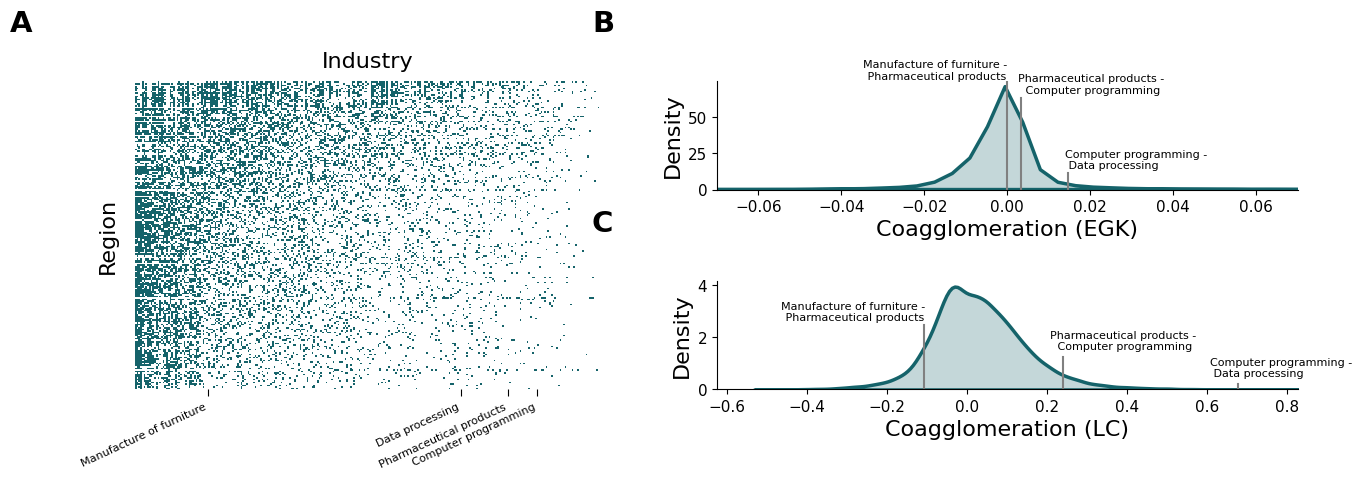

In [6]:
fig = plt.figure(figsize=(15,4))

ax = [0]*4

gs = GridSpec(2,2, figure=fig, width_ratios=[1, 1.25])
ax[0] = fig.add_subplot(gs[0:2,0])
ax[1] = fig.add_subplot(gs[0,1])
ax[2] = fig.add_subplot(gs[1,1])

fontsize = 16
fig.subplots_adjust(hspace=0.85, wspace=0.225)

# A 
mat = mcl_matrix(rca_df, key_columns=["reg", "ind", "rca01"], heatmap=False, cmap=cmap, size=fontsize)
industries = [211, 310, 620, 631]
column_positions = [mat.columns.get_loc(col) for col in industries]
column_positions[2] += 20

mcl_matrix(rca_df, key_columns=["reg", "ind", "rca01"], heatmap=True, cmap=cmap, size=fontsize, ax=ax[0])
ax[0].set_xticks(column_positions)
tick_labels = ["Pharmaceutical products", "Manufacture of furniture", "Computer programming", "Data processing"]
ax[0].set_xticklabels(tick_labels, rotation=25, ha="right", size=fontsize-8)
ax[0].xaxis.set_label_position('top')


# B-C
key_var1 = "egk_coagg"
key_var2 = "coagg_porter_rca01"


# colormap1
cvals  = [reg_df[key_var1].min(), reg_df[key_var1].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

density_plot(
    reg_df,
    key_column=key_var1,
    colorway=colors[1],
    xlabel_text="Coagglomeration (EGK)",
    fontsize=fontsize,
    ax=ax[1]
)
ax[1].axvline(x=0.014659, color="grey", linestyle='-', ymin=0, ymax=0.15)
ax[1].axvline(x=0.003439, color="grey", linestyle='-', ymin=0, ymax=0.85)
ax[1].axvline(x=-0.000175, color="grey", linestyle='-', ymin=0, ymax=1.1)
ax[1].set_xlim(-0.07, 0.07)
ax[1].set_zorder(100)
ax[1].text(0.375, 2.95, "Manufacture of furniture -\n Pharmaceutical products", ha='center', va='center', transform=plt.gca().transAxes, size=(fontsize-8))
ax[1].text(0.645, 2.825, "Pharmaceutical products -\n Computer programming", ha='center', va='center', transform=plt.gca().transAxes, size=(fontsize-8))
ax[1].text(0.6, 2.125, "Computer programming -\n Data processing", ha='left', va='center', transform=plt.gca().transAxes, size=(fontsize-8))



# colormap2
cvals  = [reg_df[key_var2].min(), reg_df[key_var2].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

density_plot(
    reg_df,
    key_column=key_var2,
    colorway=colors[1],
    xlabel_text="Coagglomeration (LC)",
    fontsize=fontsize,
    ax=ax[2]
)
ax[2].axvline(x=0.676393, color="grey", linestyle='-', ymin=0, ymax=0.05, zorder=2)
ax[2].axvline(x=0.239513, color="grey", linestyle='-', ymin=0, ymax=0.3, zorder=2)
ax[2].axvline(x=-0.107074, color="grey", linestyle='-', ymin=0, ymax=0.6, zorder=2)
ax[2].set_xlim(-0.625, 0.825)
ax[2].text(0.235, 0.7175, "Manufacture of furniture -\n Pharmaceutical products", ha='center', va='center', transform=plt.gca().transAxes, size=(fontsize-8))
ax[2].text(0.7, 0.45, "Pharmaceutical products -\n Computer programming", ha='center', va='center', transform=plt.gca().transAxes, size=(fontsize-8))
ax[2].text(0.85, 0.2, "Computer programming -\n Data processing", ha='left', va='center', transform=plt.gca().transAxes, size=(fontsize-8))


# subplot title
#for a, label in zip(ax, ['A','B','C','D']):
#    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0].annotate("A", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1].annotate("B", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[2].annotate("C", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)


# plt.savefig(f"../figures/mf01_coagglomeration.png", dpi=300, bbox_inches='tight', facecolor="white")

**Figure 2 - interplots**

In [3]:
# data from /code/95b_regressions_main.R
mf_df = pd.read_csv("../outputs/marginal_effects_for_interplots.csv", sep=";")

In [4]:
def custom_interplot(df, setting_vector, fontsize, ax=None):
    df = df[(df["dep_var"]==setting_vector[0]) & (df["y_values"]==setting_vector[1]) & (df["x_var"]==setting_vector[2])]
    
    if ax is None: 
        ax = plt.gca()
    ax.plot(df["x_values"], df["AME"], color="black", zorder=4)
    ax.plot(df["x_values"], df["upper"], color="#15636A", zorder=4)
    ax.plot(df["x_values"], df["lower"], color="#15636A", zorder=4)
    ax.fill_between(df["x_values"], df["lower"], df["upper"], color="#15636A", alpha=0.3, zorder=3)
    ax.axhline(y=0, color='black', linestyle='--', zorder=2)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

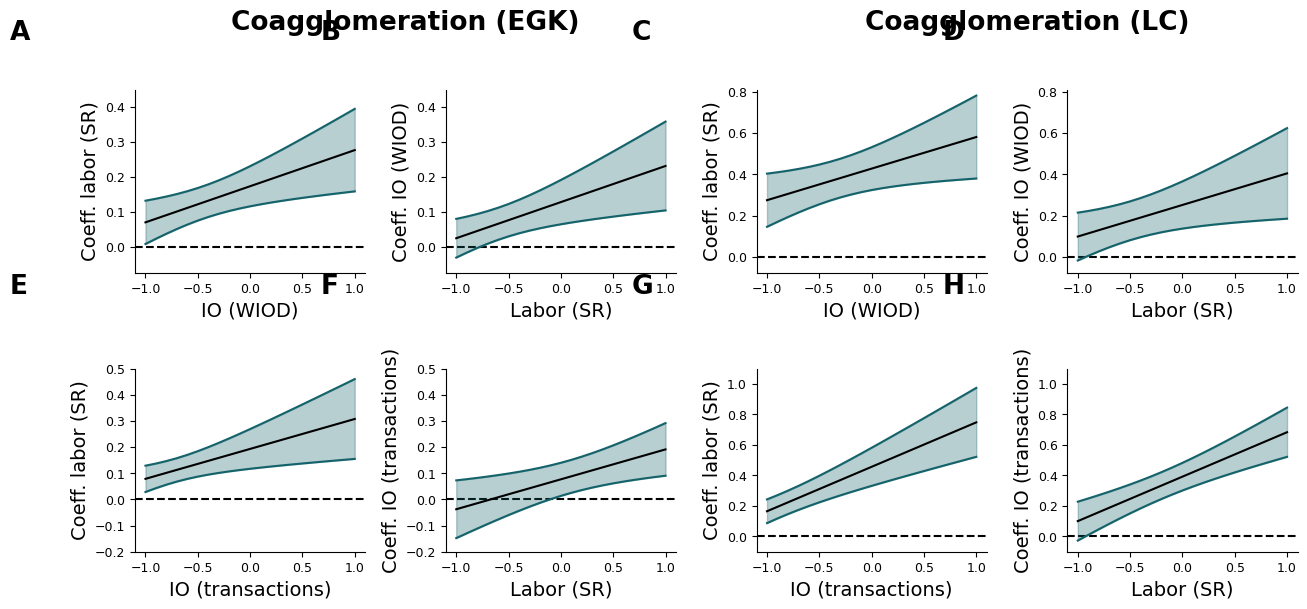

In [10]:
fig, ax = plt.subplots(2,4, figsize=(15, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.525)
fontsize=14


title_text = "Coagglomeration (EGK)"
fig.text((ax[0, 0].get_position().x0 + ax[0, 1].get_position().x1) / 2, 
         ax[0, 0].get_position().y1 + 0.1,
         title_text, ha="center", weight="bold", fontsize=fontsize+5)
title_text = "Coagglomeration (LC)"
fig.text((ax[0, 2].get_position().x0 + ax[0, 3].get_position().x1) / 2, 
         ax[0, 2].get_position().y1 + 0.1,
         title_text, ha="center", weight="bold", fontsize=fontsize+5)


custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "sr_norm", "io_wiot_hun"], fontsize=fontsize, ax=ax[0,0])
ax[0,0].set_ylim(-0.075, 0.45)
ax[0,0].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[0,0].set_xlabel("IO (WIOD)", size=fontsize)

custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "io_wiot_hun", "sr_norm"], fontsize=fontsize, ax=ax[0,1])
ax[0,1].set_ylim(-0.075, 0.45)
ax[0,1].set_ylabel("Coeff. IO (WIOD)", size=fontsize)
ax[0,1].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "sr_norm", "io_norm3"], fontsize=fontsize, ax=ax[1,0])
ax[1,0].set_ylim(-0.2, 0.5)
ax[1,0].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[1,0].set_xlabel("IO (transactions)", size=fontsize)

custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "io_norm3", "sr_norm"], fontsize=fontsize, ax=ax[1,1])
ax[1,1].set_ylim(-0.2, 0.5)
ax[1,1].set_ylabel("Coeff. IO (transactions)", size=fontsize)
ax[1,1].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "sr_norm", "io_wiot_hun"], fontsize=fontsize, ax=ax[0,2])
ax[0,2].set_ylim(-0.075, 0.81)
ax[0,2].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[0,2].set_xlabel("IO (WIOD)", size=fontsize)

custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "io_wiot_hun", "sr_norm"], fontsize=fontsize, ax=ax[0,3])
ax[0,3].set_ylim(-0.075, 0.81)
ax[0,3].set_ylabel("Coeff. IO (WIOD)", size=fontsize)
ax[0,3].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "sr_norm", "io_norm3"], fontsize=fontsize, ax=ax[1,2])
ax[1,2].set_ylim(-0.1, 1.1)
ax[1,2].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[1,2].set_xlabel("IO (transactions)", size=fontsize)

custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "io_norm3", "sr_norm"], fontsize=fontsize, ax=ax[1,3])
ax[1,3].set_ylim(-0.1, 1.1)
ax[1,3].set_ylabel("Coeff. IO (transactions)", size=fontsize)
ax[1,3].set_xlabel("Labor (SR)", size=fontsize)

ax[0,0].annotate("A", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,1].annotate("B", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,2].annotate("C", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,3].annotate("D", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,0].annotate("E", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,1].annotate("F", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,2].annotate("G", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,3].annotate("H", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)

plt.savefig(f"../figures/mf02_interplots.png", dpi=300, bbox_inches='tight', facecolor="white")

**Figure 3 - geography of skill related IO connections**

In [6]:
# matrix 1-4 -- average IO relatedness for coagglomerated and skill related industries

# SR and coagglomeration table
ii_reg = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")

def ind_ind_variables(df, colocation_variable):
    """function to speed up test with different coagglomeration measures"""
    df["sr01"] = (df["sr_norm"] > 0).astype(int)
    #df["colocation_median01"] = (df[colocation_variable] > df[colocation_variable].median()).astype(int)
    df["colocation01"] = (df[colocation_variable] > 0).astype(int)
    return df

ii_table = ind_ind_variables(ii_reg, colocation_variable="coagg_porter_rca01")
ii_table["io01"] = (ii_table["io_norm3"] > 0).astype(int)

# make a clean matrix
ii_mat = pd.pivot_table(ii_table,
        #values="io_norm3",
        values="io01",
        index="sr01",
        columns="colocation01",
        aggfunc="sum",
        margins=False)

io_mat_norm = ii_mat / ii_mat.sum()
#io_mat_norm = ii_mat / ii_mat.sum().sum()
#ii_mat.sort_values(by="sr01", ascending=False, inplace=True)
io_mat_norm.sort_values(by="sr01", ascending=False, inplace=True)

In [7]:
# new data from the Databank
ff_table = pd.read_csv("../data/oc18_2025_jan/crosstabs_io_ties_sr01_same_region.csv", sep=";")

def ff_mat_creation(df):
    ff_mat = pd.pivot_table(df,
        values="nr_io",
        index="sr01",
        columns="same_region",
        aggfunc="sum",
        margins=False)

    ff_mat_norm = ff_mat / ff_mat.sum()
    #ff_mat_norm = ff_mat / ff_mat.sum().sum()
    ff_mat_norm.sort_values(by="sr01", ascending=False, inplace=True)
    return ff_mat_norm

ff_mat1 = ff_mat_creation(ff_table[ff_table["region"]=="nuts3"])
ff_mat2 = ff_mat_creation(ff_table[ff_table["region"]=="nuts4"])
ff_mat3 = ff_mat_creation(ff_table[ff_table["region"]=="dist10"])

In [8]:
def crosstab_visual(mat, fontsize, colormap, title_text=None, axis_labels=None, ax=None):
    if ax is None:
        ax = plt.gca()
    mh = sns.heatmap(
        mat,
        annot=True,
        annot_kws={"fontsize":(fontsize)},
        fmt=".2f",
        cbar=False,
        cmap=colormap,
        ax=ax
    )

    if axis_labels:
        ax.set_xlabel(axis_labels[0], fontsize=fontsize)
        ax.set_ylabel(axis_labels[1], fontsize=fontsize)
    
    if title_text:
        ax.set_title(title_text, fontsize=fontsize)

    # adding a white vertical line at the center
    center_col = mat.shape[1] // 2
    ax.axvline(center_col, color="white", linewidth=2)

In [9]:
# OC data in -- for tie geography
ddf = pd.read_csv("../data/oc15_2023_dec/oc_distance_io_labor_ties.csv", sep=";")
ddf = ddf.fillna(0)

In [10]:
# re-bin distance below 50 km
factors = [10, 25, 50]
for factor in factors:
    ddf[f'dist_int{factor}'] = np.floor(ddf['dist_int'] / factor) * factor

# re-bin distance above 50 km
conditions = [
    (ddf["dist_int"] < 50),
    (ddf["dist_int"] >= 50) & (ddf["dist_int"] < 100),
    (ddf["dist_int"] >= 100) & (ddf["dist_int"] < 200),
    (ddf["dist_int"] >= 200) & (ddf["dist_int"] < 500),
    (ddf["dist_int"] >= 500),
]

choices = [
    ddf["dist_int"],
    ddf["dist_int10"],
    ddf["dist_int25"],
    ddf["dist_int50"],
    np.nan,
]

ddf["dist_combined"] = np.select(conditions, choices, default=np.nan)

In [11]:
# group by dist_combined and calculate aggregated values
agg_cols = ["poss_ties", "obs_io", "obs_labor", "obs_overlap", "nr_io_sr_ties", "io_diff_ind"]
ddf2 = ddf.groupby(["dist_combined"])[agg_cols].sum().reset_index()

# calculate probabilities
prob_cols = ["prob_io", "prob_labor", "prob_overlap"]
ddf2[prob_cols] = ddf2[["obs_io", "obs_labor", "obs_overlap"]].div(ddf2["poss_ties"], axis=0)

# calculate logs
ddf2["log_dist_combined"] = np.log10(ddf2["dist_combined"] + 1)
ddf2[[f"log_{col}" for col in prob_cols]] = ddf2[prob_cols].apply(lambda x: np.log10(x))

# standard errors for proportions sqrt(p*(1-p)/n) -- p : proportion, n : sample size
ddf2["se_io"] = np.sqrt(ddf2["prob_io"]*(1-ddf2["prob_io"]) / np.sqrt(ddf2["poss_ties"]))
ddf2["se_labor"] = np.sqrt(ddf2["prob_labor"]*(1-ddf2["prob_labor"]) / np.sqrt(ddf2["poss_ties"]))
ddf2["se_overlap"] = np.sqrt(ddf2["prob_overlap"]*(1-ddf2["prob_overlap"]) / np.sqrt(ddf2["poss_ties"]))

# calculate confidence intervals
ddf2["log_prob_labor_conf_up"] = ddf2["log_prob_labor"] - 1.96*(ddf2["se_labor"])
ddf2["log_prob_labor_conf_down"] = ddf2["log_prob_labor"] + 1.96*(ddf2["se_labor"])
ddf2["log_prob_io_conf_up"] = ddf2["log_prob_io"] - 1.96*(ddf2["se_io"])
ddf2["log_prob_io_conf_down"] = ddf2["log_prob_io"] + 1.96*(ddf2["se_io"])
ddf2["log_prob_overlap_conf_up"] = ddf2["log_prob_overlap"] - 1.96*(ddf2["se_overlap"])
ddf2["log_prob_overlap_conf_down"] = ddf2["log_prob_overlap"] + 1.96*(ddf2["se_overlap"])

/opt/homebrew/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [12]:
def tie_distance(df, distance_column, var_color_dict, fontsize, yaxis_text, legend_dict, ax=None):
    """function for different x: distance y: ties plots"""
    
    # data preparation
    all_columns = distance_column + list(var_color_dict.keys())
    df = df[all_columns]

    # figure preparation
    if ax is None:
        ax = plt.gca()
    for key, value in var_color_dict.items():
        ax.plot(df[distance_column], df[key], "o-", color=value, markersize=5, linewidth=3, label=legend_dict[key])
        ax.set_xlabel("Distance in km (log)", size=fontsize)
        ax.set_ylabel(yaxis_text, size=fontsize)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

In [13]:
# calculations for SR / no-SR supplier connections
ddf2["nr_io_no_sr_ties"] = ddf2["io_diff_ind"] - ddf2["nr_io_sr_ties"]
ddf2["nr_io_no_sr_ties_total"] = ddf2["nr_io_no_sr_ties"].sum()
ddf2["nr_io_sr_ties_total"] = ddf2["nr_io_sr_ties"].sum()

# shares
ddf2["share_io_no_sr_ties"] = ddf2["nr_io_no_sr_ties"] / ddf2["nr_io_no_sr_ties_total"]
ddf2["share_io_sr_ties"] = ddf2["nr_io_sr_ties"] / ddf2["nr_io_sr_ties_total"]

# standard errors for proportions sqrt(p*(1-p)/n) -- p : proportion, n : sample size
ddf2["se_io_no_sr"] = np.sqrt(ddf2["share_io_no_sr_ties"]*(1-ddf2["share_io_no_sr_ties"])) / np.sqrt(ddf2["nr_io_sr_ties_total"])
ddf2["share_io_no_sr_ties_ci"] = 1.96*(ddf2["se_io_no_sr"])
#ddf2["share_io_no_sr_ties_ci"] = ddf2["share_io_no_sr_ties"] - 1.96*(ddf2["se_io_no_sr"])
#ddf2["share_io_no_sr_ties_L"] = ddf2["share_io_no_sr_ties"] + 1.96*(ddf2["se_io_no_sr"])

ddf2["se_io_sr"] = np.sqrt(ddf2["share_io_sr_ties"]*(1-ddf2["share_io_sr_ties"])) / np.sqrt(ddf2["nr_io_sr_ties_total"])
ddf2["share_io_sr_ties_ci"] = 1.96*(ddf2["se_io_sr"])
#ddf2["share_io_no_sr_ties_L"] = ddf2["share_io_no_sr_ties"] + 1.96*(ddf2["se_for_plot"])


/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_52341/2555113483.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[4].set_xticklabels(["", "$10^0$", "", "$10^1$", "", "$10^1$", "", "$10^2$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_52341/2555113483.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[4].set_yticklabels(["", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$"], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_52341/2555113483.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  limited_

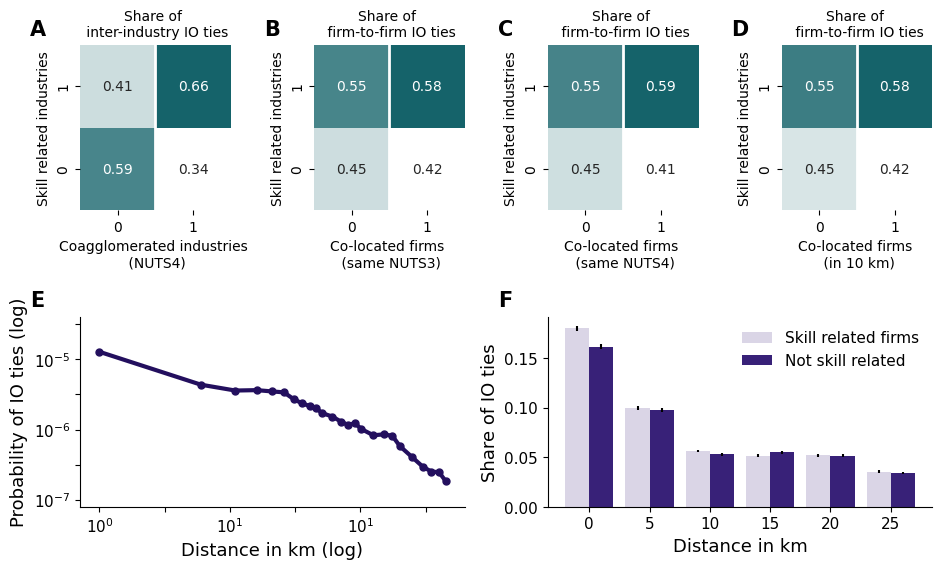

In [14]:
# distance decay figure
fig = plt.figure(figsize=(11,6))
ax = [0]*6

gs = GridSpec(2,4, figure=fig, height_ratios=[1, 1.15])
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
ax[2] = fig.add_subplot(gs[0,2])
ax[3] = fig.add_subplot(gs[0,3])
ax[4] = fig.add_subplot(gs[1,0:2])
ax[5] = fig.add_subplot(gs[1,2:])

fontsize = 13
fig.subplots_adjust(hspace=0.6, wspace=0.55)


# A-D -- column normalized matrices
crosstab_visual(
    io_mat_norm,
    fontsize=fontsize-3,
    colormap=cmap,
    title_text="Share of \n inter-industry IO ties",
    axis_labels=["Coagglomerated industries \n (NUTS4)", "Skill related industries"],
    ax=ax[0]
)

crosstab_visual(
    ff_mat1,
    fontsize=fontsize-3,
    colormap=cmap,
    title_text="Share of \n firm-to-firm IO ties",
    axis_labels=[f"Co-located firms \n (same NUTS3)", "Skill related industries"],
    ax=ax[1]
)

crosstab_visual(
    ff_mat2,
    fontsize=fontsize-3,
    colormap=cmap,
    title_text="Share of \n firm-to-firm IO ties",
    axis_labels=["Co-located firms \n (same NUTS4)", "Skill related industries"],
    ax=ax[2]
)

crosstab_visual(
    ff_mat3,
    fontsize=fontsize-3,
    colormap=cmap,
    title_text="Share of \n firm-to-firm IO ties",
    axis_labels=["Co-located firms \n (in 10 km)", "Skill related industries"],
    ax=ax[3]
)


# E -- probability of ties
ax[4].plot(ddf2["log_dist_combined"], ddf2["log_prob_io"], "o-", color="#230F5E", markersize=5, linewidth=3)
ax[4].set_xticklabels(["", "$10^0$", "", "$10^1$", "", "$10^1$", "", "$10^2$", ""], size=fontsize-2)
#print(ax[4].get_xlim())
#print(ax[4].get_ylim())
ax[4].set_xlim(-0.15, 2.8)
ax[4].set_ylim(-7.1, -4.4)
ax[4].set_yticklabels(["", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$"], size=fontsize-2)
ax[4].set_xlabel("Distance in km (log)", size=fontsize)
ax[4].set_ylabel("Probability of IO ties (log)", size=fontsize)
ax[4].spines['top'].set_visible(False)
ax[4].spines['right'].set_visible(False)


# F -- barplot version
limited_df = ddf2[ddf2["dist_combined"] <= 25]
limited_df["dist_combined"] = limited_df["dist_combined"].astype(int)

bar_width = 0.40
index = np.arange(len(limited_df["dist_combined"]))

ax[5].bar(
        index,
        limited_df["share_io_sr_ties"],
        bar_width,
        label="Skill related firms",
        yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        capsize=0,
        color="#dad5e6"
)
ax[5].bar(
        index + bar_width,
        limited_df["share_io_no_sr_ties"],
        bar_width,
        label="Not skill related",
        yerr=[limited_df["share_io_no_sr_ties_ci"], limited_df["share_io_no_sr_ties_ci"]],
        capsize=0,
        color="#382178"
)
ax[5].set_xticks(index + bar_width / 2, limited_df["dist_combined"], size=fontsize-2)
ax[5].set_xlabel("Distance in km", size=fontsize)
ax[5].set_ylabel("Share of IO ties", size=fontsize)
ax[5].tick_params("y", labelsize=(fontsize-2))
ax[5].spines['top'].set_visible(False)
ax[5].spines['right'].set_visible(False)
ax[5].legend(loc="upper right", prop={'size': fontsize-2}, frameon=False)

# subplot title
labels = list(string.ascii_uppercase)[:len(ax)]
for i, label in enumerate(labels):
    ax[i].annotate(
        label, 
        xy=(0, 1), 
        xycoords="axes fraction", 
        xytext=(-50, 10),
        #xytext=(-120, 40),
        textcoords="offset pixels", 
        weight="bold", 
        size=fontsize + 2
    )

# plt.savefig(f"../figures/mf03_geography_of_io_ties.png", dpi=300, bbox_inches='tight', facecolor="white")

**new version -- wip**

In [46]:
# SR and coagglomeration table
ii_reg = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")

def ind_ind_variables(df, colocation_variable):
    """function to speed up test with different coagglomeration measures"""
    df["sr01"] = (df["sr_norm"] > 0).astype(int)
    #df["colocation_median01"] = (df[colocation_variable] > df[colocation_variable].median()).astype(int)
    df["colocation01"] = (df[colocation_variable] > 0).astype(int)
    return df

ii_table = ind_ind_variables(ii_reg, colocation_variable="coagg_porter_rca01")
ii_table["io01"] = (ii_table["io_norm3"] > 0).astype(int)
ii_table = ii_table[ii_table["ind1"] < ii_table["ind2"]]

io_ii_sr = ii_table[(ii_table["io01"]==1) & (ii_table["colocation01"]==1)]
io_ii_nosr = ii_table[(ii_table["io01"]==1) & (ii_table["colocation01"]==0)]

,sr_norm,colocation01,io01
1,0.773167,1,1
2,0.766772,1,1
3,0.792705,1,1
4,0.906011,1,1
5,0.836312,1,1
...,...,...,...
69403,-0.029496,1,1
69404,0.607798,1,1
69405,0.286493,1,1
70191,-0.500000,1,1


In [48]:
# means
print(io_ii_sr["sr_norm"].mean())
print(io_ii_nosr["sr_norm"].mean())

# two-sample t-test
t_stat, p_value = stats.ttest_ind(io_ii_sr["sr_norm"], io_ii_nosr["sr_norm"])

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

0.1340536254350465
-0.11590768340994996
T-statistic: 11.5915
P-value: 0.0000


In [57]:
np.std(io_ii_sr["sr_norm"])

np.float64(0.45182949850779053)

In [58]:
pd.DataFrame([np.mean(io_ii_sr["sr_norm"]), np.std(io_ii_sr["sr_norm"]), len(io_ii_sr["sr_norm"])])

,0
0,0.134054
1,0.451829
2,1996.000000


In [17]:
# data IN
tdf = pd.read_csv("../data/oc19_2025_mar/coloc_sr_io_connections.csv", sep=";")

In [50]:
def coeff_from_oc_data(df, fontsize, mean_sd_n_list=None, ax=None):
    if mean_sd_n_list is None:
        # data prep
        mean_coloc = df.loc[df["variable"] == "mean", "coloc"].values[0]
        mean_no_coloc = df.loc[df["variable"] == "mean", "no_coloc"].values[0]
        sd_coloc = df.loc[df["variable"] == "sd", "coloc"].values[0]
        sd_no_coloc = df.loc[df["variable"] == "sd", "no_coloc"].values[0]
        n_coloc = df.loc[df["variable"] == "n", "coloc"].values[0]
        n_no_coloc = df.loc[df["variable"] == "n", "no_coloc"].values[0]
    else:
        mean_coloc = mean_sd_n_list[0]
        mean_no_coloc = mean_sd_n_list[1]
        sd_coloc = mean_sd_n_list[2]
        sd_no_coloc = mean_sd_n_list[3]
        n_coloc = mean_sd_n_list[4]
        n_no_coloc = mean_sd_n_list[5]

    # compute 95% confidence intervals
    ci_coloc = 1.96 * (sd_coloc / np.sqrt(n_coloc))
    ci_no_coloc = 1.96 * (sd_no_coloc / np.sqrt(n_no_coloc))

    # plot setup
    x_positions = [1.25, 1.75]
    
    if ax is None:
        ax = plt.gca()
    ax.scatter(x_positions, [mean_no_coloc, mean_coloc], color=["grey", "#15636A"], s=70, zorder=3)

    # vertical lines for confidence intervals
    ax.vlines(x_positions, 
            [mean_no_coloc + ci_no_coloc, mean_coloc + ci_coloc],
            [mean_no_coloc - ci_no_coloc, mean_coloc - ci_coloc],
            colors=["black", "black"], linewidth=1, zorder=2)

    ax.set_xticks(x_positions)
    ax.set_xlim(1, 2)
    ax.set_xticklabels(["0", "1"])
    #ax.set_xlabel("Co-located firms \n (same NUTS3)", size=fontsize)
    ax.set_ylabel("Average skill relatedness", size=fontsize)
    ax.set_title("Firm-to-firm IO ties", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
        

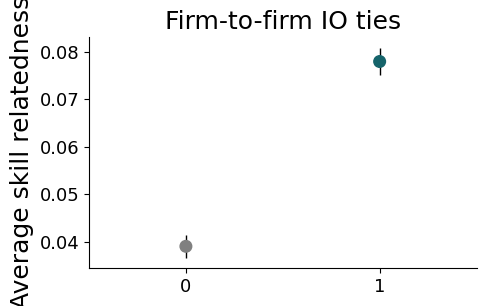

In [51]:
temp = tdf[tdf["region"]=="nuts3"]

fig, ax = plt.subplots(1,1, figsize=(5,3))
coeff_from_oc_data(temp, fontsize=18, ax=ax)

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_52341/3483708535.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[4].set_xticklabels(["", "$10^0$", "", "$10^1$", "", "$10^1$", "", "$10^2$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_52341/3483708535.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[4].set_yticklabels(["", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$"], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_52341/3483708535.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  limited_

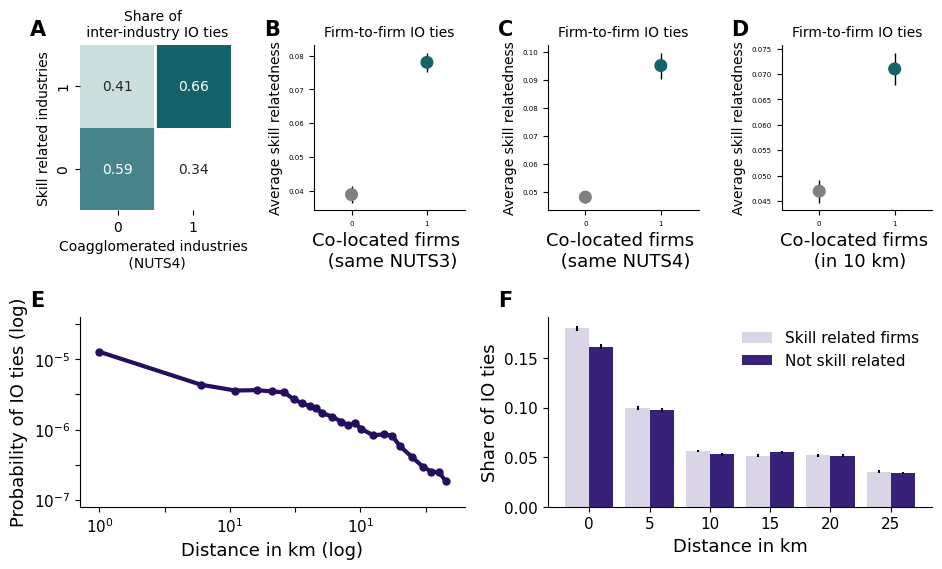

In [24]:
# distance decay figure
fig = plt.figure(figsize=(11,6))
ax = [0]*6

gs = GridSpec(2,4, figure=fig, height_ratios=[1, 1.15])
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
ax[2] = fig.add_subplot(gs[0,2])
ax[3] = fig.add_subplot(gs[0,3])
ax[4] = fig.add_subplot(gs[1,0:2])
ax[5] = fig.add_subplot(gs[1,2:])

fontsize = 13
fig.subplots_adjust(hspace=0.6, wspace=0.55)


# A-D -- column normalized matrices
coeff(
    
)

coeff_from_oc_data(
    tdf[tdf["region"]=="nuts3"],
    fontsize=fontsize-3,
    ax=ax[1]
)
ax[1].set_xlabel("Co-located firms \n (same NUTS3)", size=fontsize)

coeff_from_oc_data(
    tdf[tdf["region"]=="nuts4"],
    fontsize=fontsize-3,
    ax=ax[2]
)
ax[2].set_xlabel("Co-located firms \n (same NUTS4)", size=fontsize)

coeff_from_oc_data(
    tdf[tdf["region"]=="in10km"],
    fontsize=fontsize-3,
    ax=ax[3]
)
ax[3].set_xlabel("Co-located firms \n (in 10 km)", size=fontsize)


# E -- probability of ties
ax[4].plot(ddf2["log_dist_combined"], ddf2["log_prob_io"], "o-", color="#230F5E", markersize=5, linewidth=3)
ax[4].set_xticklabels(["", "$10^0$", "", "$10^1$", "", "$10^1$", "", "$10^2$", ""], size=fontsize-2)
#print(ax[4].get_xlim())
#print(ax[4].get_ylim())
ax[4].set_xlim(-0.15, 2.8)
ax[4].set_ylim(-7.1, -4.4)
ax[4].set_yticklabels(["", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$"], size=fontsize-2)
ax[4].set_xlabel("Distance in km (log)", size=fontsize)
ax[4].set_ylabel("Probability of IO ties (log)", size=fontsize)
ax[4].spines['top'].set_visible(False)
ax[4].spines['right'].set_visible(False)


# F -- barplot version
limited_df = ddf2[ddf2["dist_combined"] <= 25]
limited_df["dist_combined"] = limited_df["dist_combined"].astype(int)

bar_width = 0.40
index = np.arange(len(limited_df["dist_combined"]))

ax[5].bar(
        index,
        limited_df["share_io_sr_ties"],
        bar_width,
        label="Skill related firms",
        yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        capsize=0,
        color="#dad5e6"
)
ax[5].bar(
        index + bar_width,
        limited_df["share_io_no_sr_ties"],
        bar_width,
        label="Not skill related",
        yerr=[limited_df["share_io_no_sr_ties_ci"], limited_df["share_io_no_sr_ties_ci"]],
        capsize=0,
        color="#382178"
)
ax[5].set_xticks(index + bar_width / 2, limited_df["dist_combined"], size=fontsize-2)
ax[5].set_xlabel("Distance in km", size=fontsize)
ax[5].set_ylabel("Share of IO ties", size=fontsize)
ax[5].tick_params("y", labelsize=(fontsize-2))
ax[5].spines['top'].set_visible(False)
ax[5].spines['right'].set_visible(False)
ax[5].legend(loc="upper right", prop={'size': fontsize-2}, frameon=False)

# subplot title
labels = list(string.ascii_uppercase)[:len(ax)]
for i, label in enumerate(labels):
    ax[i].annotate(
        label, 
        xy=(0, 1), 
        xycoords="axes fraction", 
        xytext=(-50, 10),
        #xytext=(-120, 40),
        textcoords="offset pixels", 
        weight="bold", 
        size=fontsize + 2
    )

# plt.savefig(f"../figures/mf03_geography_of_io_ties.png", dpi=300, bbox_inches='tight', facecolor="white")

**Figure 2 - distance of ties -- v2**

In [3]:
# OC data in
ddf = pd.read_csv("../data/oc15_2023_dec/oc_distance_io_labor_ties.csv", sep=";")
ddf = ddf.fillna(0)

In [4]:
# re-bin distance below 50 km
factors = [10, 25, 50]
for factor in factors:
    ddf[f'dist_int{factor}'] = np.floor(ddf['dist_int'] / factor) * factor

# re-bin distance above 50 km
conditions = [
    (ddf["dist_int"] < 50),
    (ddf["dist_int"] >= 50) & (ddf["dist_int"] < 100),
    (ddf["dist_int"] >= 100) & (ddf["dist_int"] < 200),
    (ddf["dist_int"] >= 200) & (ddf["dist_int"] < 500),
    (ddf["dist_int"] >= 500),
]

choices = [
    ddf["dist_int"],
    ddf["dist_int10"],
    ddf["dist_int25"],
    ddf["dist_int50"],
    np.nan,
]

ddf["dist_combined"] = np.select(conditions, choices, default=np.nan)

In [5]:
# group by dist_combined and calculate aggregated values
agg_cols = ["poss_ties", "obs_io", "obs_labor", "obs_overlap", "nr_io_sr_ties", "io_diff_ind"]
ddf2 = ddf.groupby(["dist_combined"])[agg_cols].sum().reset_index()

# calculate probabilities
prob_cols = ["prob_io", "prob_labor", "prob_overlap"]
ddf2[prob_cols] = ddf2[["obs_io", "obs_labor", "obs_overlap"]].div(ddf2["poss_ties"], axis=0)

# calculate logs
ddf2["log_dist_combined"] = np.log10(ddf2["dist_combined"] + 1)
ddf2[[f"log_{col}" for col in prob_cols]] = ddf2[prob_cols].apply(lambda x: np.log10(x))

# standard errors for proportions sqrt(p*(1-p)/n) -- p : proportion, n : sample size
ddf2["se_io"] = np.sqrt(ddf2["prob_io"]*(1-ddf2["prob_io"]) / np.sqrt(ddf2["poss_ties"]))
ddf2["se_labor"] = np.sqrt(ddf2["prob_labor"]*(1-ddf2["prob_labor"]) / np.sqrt(ddf2["poss_ties"]))
ddf2["se_overlap"] = np.sqrt(ddf2["prob_overlap"]*(1-ddf2["prob_overlap"]) / np.sqrt(ddf2["poss_ties"]))

# calculate confidence intervals
ddf2["log_prob_labor_conf_up"] = ddf2["log_prob_labor"] - 1.96*(ddf2["se_labor"])
ddf2["log_prob_labor_conf_down"] = ddf2["log_prob_labor"] + 1.96*(ddf2["se_labor"])
ddf2["log_prob_io_conf_up"] = ddf2["log_prob_io"] - 1.96*(ddf2["se_io"])
ddf2["log_prob_io_conf_down"] = ddf2["log_prob_io"] + 1.96*(ddf2["se_io"])
ddf2["log_prob_overlap_conf_up"] = ddf2["log_prob_overlap"] - 1.96*(ddf2["se_overlap"])
ddf2["log_prob_overlap_conf_down"] = ddf2["log_prob_overlap"] + 1.96*(ddf2["se_overlap"])

/opt/homebrew/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
def tie_distance(df, distance_column, var_color_dict, fontsize, yaxis_text, legend_dict, ax=None):
    """function for different x: distance y: ties plots"""
    
    # data preparation
    all_columns = distance_column + list(var_color_dict.keys())
    df = df[all_columns]

    # figure preparation
    if ax is None:
        ax = plt.gca()
    for key, value in var_color_dict.items():
        ax.plot(df[distance_column], df[key], "o-", color=value, markersize=5, linewidth=3, label=legend_dict[key])
        ax.set_xlabel("Distance in km (log)", size=fontsize)
        ax.set_ylabel(yaxis_text, size=fontsize)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

In [7]:
# calculations for SR / no-SR supplier connections
ddf2["nr_io_no_sr_ties"] = ddf2["io_diff_ind"] - ddf2["nr_io_sr_ties"]
ddf2["nr_io_no_sr_ties_total"] = ddf2["nr_io_no_sr_ties"].sum()
ddf2["nr_io_sr_ties_total"] = ddf2["nr_io_sr_ties"].sum()

# shares
ddf2["share_io_no_sr_ties"] = ddf2["nr_io_no_sr_ties"] / ddf2["nr_io_no_sr_ties_total"]
ddf2["share_io_sr_ties"] = ddf2["nr_io_sr_ties"] / ddf2["nr_io_sr_ties_total"]

# standard errors for proportions sqrt(p*(1-p)/n) -- p : proportion, n : sample size
ddf2["se_io_no_sr"] = np.sqrt(ddf2["share_io_no_sr_ties"]*(1-ddf2["share_io_no_sr_ties"])) / np.sqrt(ddf2["nr_io_sr_ties_total"])
ddf2["share_io_no_sr_ties_ci"] = 1.96*(ddf2["se_io_no_sr"])
#ddf2["share_io_no_sr_ties_ci"] = ddf2["share_io_no_sr_ties"] - 1.96*(ddf2["se_io_no_sr"])
#ddf2["share_io_no_sr_ties_L"] = ddf2["share_io_no_sr_ties"] + 1.96*(ddf2["se_io_no_sr"])

ddf2["se_io_sr"] = np.sqrt(ddf2["share_io_sr_ties"]*(1-ddf2["share_io_sr_ties"])) / np.sqrt(ddf2["nr_io_sr_ties_total"])
ddf2["share_io_sr_ties_ci"] = 1.96*(ddf2["se_io_sr"])
#ddf2["share_io_no_sr_ties_L"] = ddf2["share_io_no_sr_ties"] + 1.96*(ddf2["se_for_plot"])


In [8]:
def ei_data_manipulation(path):
    ei_df = pd.read_csv(path, sep=";")
    if len(ei_df["ei_bin"])==21:
        ei_df["group"] = [-1, -1, -0.8, 0.8, -0.6, -0.6, -0.4, -0.4, -0.2, -0.2, 0, 0.2, 0.2, 0.4, 0.4, 0.6, 0.6, 0.8, 0.8, 1, 1]
    else:
        ei_df["group"] = [-1, -0.8, 0.8, -0.6, -0.6, -0.4, -0.4, -0.2, -0.2, 0, 0.2, 0.2, 0.4, 0.4, 0.6, 0.6, 0.8, 0.8, 1, 1]
    
    ei_df["labor_obs2"] = ei_df.groupby("group")["labor_obs"].transform("sum")
    ei_df["io_obs2"] = ei_df.groupby("group")["io_obs"].transform("sum")
    
    ei_df["total_labor"] = ei_df["labor_obs"].sum()
    ei_df["total_io"] = ei_df["io_obs"].sum()
    ei_df["labor_norm"] = ei_df["labor_obs2"] / ei_df["total_labor"]
    ei_df["io_norm"] = ei_df["io_obs2"] / ei_df["total_io"]

    ei_df["se_io_norm"] = np.sqrt(ei_df["io_norm"]*(1-ei_df["io_norm"])) / np.sqrt(ei_df["total_io"])
    ei_df["io_norm_ci"] = 1.96*(ei_df["se_io_norm"])
    ei_df["se_labor_norm"] = np.sqrt(ei_df["labor_norm"]*(1-ei_df["labor_norm"])) / np.sqrt(ei_df["total_labor"])
    ei_df["labor_norm_ci"] = 1.96*(ei_df["se_labor_norm"])

    ei_df = ei_df[["group", "labor_norm", "io_norm", "io_norm_ci", "labor_norm_ci"]].drop_duplicates()
    return ei_df

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_62746/2583216523.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_62746/2583216523.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_62746/2583216523.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

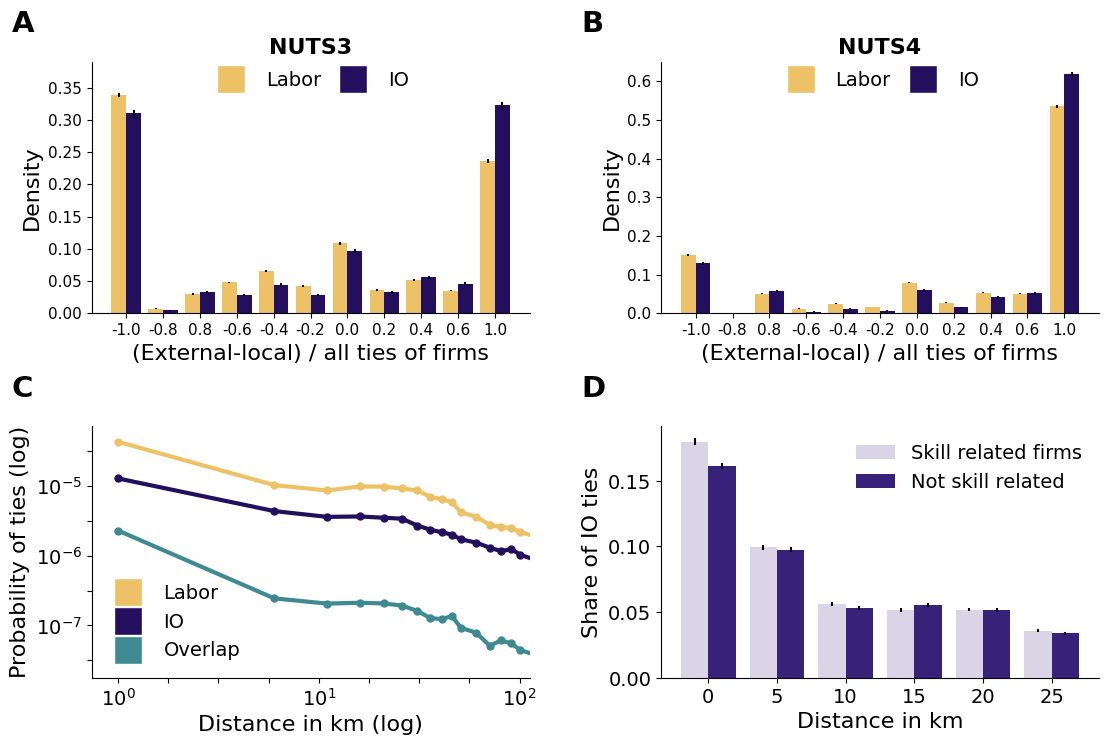

In [39]:
# distance decay figure
fig, ax = plt.subplots(2,2, figsize=(13,8))
plt.subplots_adjust(wspace=0.3, hspace=0.45)
fontsize=16



# A -- NUTS3
ei_df = ei_data_manipulation(f"../data/oc15_2023_dec/oc_ei_{region_levels[0].upper()}.csv")
bar_width = 0.4
index = np.arange(len(ei_df["group"]))
ax[0,0].bar(
        index,
        ei_df["labor_norm"],
        bar_width,
        yerr=[ei_df["labor_norm_ci"], ei_df["labor_norm_ci"]],
        capsize=0,
        color="#EDC266"
)
ax[0,0].bar(
        index + bar_width,
        ei_df["io_norm"],
        bar_width,
        yerr=[ei_df["io_norm_ci"], ei_df["io_norm_ci"]],
        capsize=0,
        color="#230F5E"
)
ax[0,0].set_xticks(index + bar_width / 2, ei_df["group"], size=fontsize-2)
ax[0,0].tick_params("x", labelsize=(fontsize-5))
ax[0,0].tick_params("y", labelsize=(fontsize-5))
ax[0,0].spines['top'].set_visible(False)
ax[0,0].spines['right'].set_visible(False)
ax[0,0].set_title("NUTS3", size=fontsize, weight="bold")
ax[0,0].set_ylim(0, 0.39)
ax[0,0].set_xlabel("(External-local) / all ties of firms", size=fontsize)
ax[0,0].set_ylabel("Density", size=fontsize)
custom_legend = [
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#EDC266", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#230F5E", markersize=20)
]
ax[0,0].legend(custom_legend, ["Labor", "IO",], loc="upper center", bbox_to_anchor=(0.5, 1.035), prop={'size': fontsize-2}, frameon=False, ncol=2, columnspacing=0.65)

# B -- NUTS4
ei_df = ei_data_manipulation(f"../data/oc15_2023_dec/oc_ei_{region_levels[1].upper()}.csv")
bar_width = 0.4
index = np.arange(len(ei_df["group"]))
ax[0,1].bar(
        index,
        ei_df["labor_norm"],
        bar_width,
        yerr=[ei_df["labor_norm_ci"], ei_df["labor_norm_ci"]],
        capsize=0,
        color="#EDC266"
)
ax[0,1].bar(
        index + bar_width,
        ei_df["io_norm"],
        bar_width,
        yerr=[ei_df["io_norm_ci"], ei_df["io_norm_ci"]],
        capsize=0,
        color="#230F5E"
)
ax[0,1].set_xticks(index + bar_width / 2, ei_df["group"], size=fontsize-2)
ax[0,1].tick_params("x", labelsize=(fontsize-5))
ax[0,1].tick_params("y", labelsize=(fontsize-5))
ax[0,1].spines['top'].set_visible(False)
ax[0,1].spines['right'].set_visible(False)
ax[0,1].set_title("NUTS4", size=fontsize, weight="bold")
ax[0,1].set_ylim(0, 0.39)
ax[0,1].set_xlabel("(External-local) / all ties of firms", size=fontsize)
ax[0,1].set_ylabel("Density", size=fontsize)
ax[0,1].set_ylim(0, 0.65)
ax[0,1].legend(custom_legend, ["Labor", "IO",], loc="upper center", bbox_to_anchor=(0.5, 1.035), prop={'size': fontsize-2}, frameon=False, ncol=2, columnspacing=0.65)



# C -- probability of ties
color_dict = {"log_prob_labor":"#EDC266", "log_prob_io":"#230F5E", "log_prob_overlap":"#3F8990"}
legend_text = {"log_prob_labor":"Labor", "log_prob_io":"IO", "log_prob_overlap":"Labor and IO"}
tie_distance(
    ddf2,
    distance_column=["log_dist_combined"],
    var_color_dict=color_dict,
    fontsize=fontsize,
    yaxis_text="Probability of ties (log)",
    legend_dict=legend_text,
    ax=ax[1,0]
)
ax[1,0].set_xlim(-0.13270882709389803, 2.05)
ax[1,0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)
#print(ax[0].get_xlim())
ax[1,0].set_ylim(-7.75, -4.15)
ax[1,0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
custom_legend = [
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#EDC266", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#230F5E", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#3F8990", markersize=20)
]
ax[1,0].legend(custom_legend, ["Labor", "IO", "Overlap"], loc="lower left", prop={'size': fontsize-2}, frameon=False)


# D -- barplot version
limited_df = ddf2[ddf2["dist_combined"] <= 25]
limited_df["dist_combined"] = limited_df["dist_combined"].astype(int)

bar_width = 0.40
index = np.arange(len(limited_df["dist_combined"]))

ax[1,1].bar(
        index,
        limited_df["share_io_sr_ties"],
        bar_width,
        label="Skill related firms",
        yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        capsize=0,
        #color="#EDC266"
        #color="#e6e3ed"
        color="#dad5e6"
)

ax[1,1].bar(
        index + bar_width,
        limited_df["share_io_no_sr_ties"],
        bar_width,
        label="Not skill related",
        yerr=[limited_df["share_io_no_sr_ties_ci"], limited_df["share_io_no_sr_ties_ci"]],
        capsize=0,
        color="#382178"
)
ax[1,1].set_xticks(index + bar_width / 2, limited_df["dist_combined"], size=fontsize-2)
ax[1,1].set_xlabel("Distance in km", size=fontsize)
ax[1,1].set_ylabel("Share of IO ties", size=fontsize)
ax[1,1].tick_params("y", labelsize=(fontsize-2))
ax[1,1].spines['top'].set_visible(False)
ax[1,1].spines['right'].set_visible(False)
ax[1,1].legend(loc="upper right", prop={'size': fontsize-2}, frameon=False)


# subplot title
labels = list(string.ascii_uppercase)[:ax.size]
for i, label in enumerate(labels):
    row, col = divmod(i, ax.shape[1])
    ax[row, col].annotate(label, xy=(0, 1), xycoords='axes fraction', xytext=(-80, 30), textcoords='offset pixels', weight='bold', size=fontsize + 5)


# plt.savefig(f"../figures/mf03_combined_firm-to-firm.png", dpi=300, bbox_inches='tight', facecolor="white")

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_27249/2598184273.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_27249/2598184273.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_27249/2598184273.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  limited_df["dist_combined"] = limited_df["dist_combined"].astype(int)


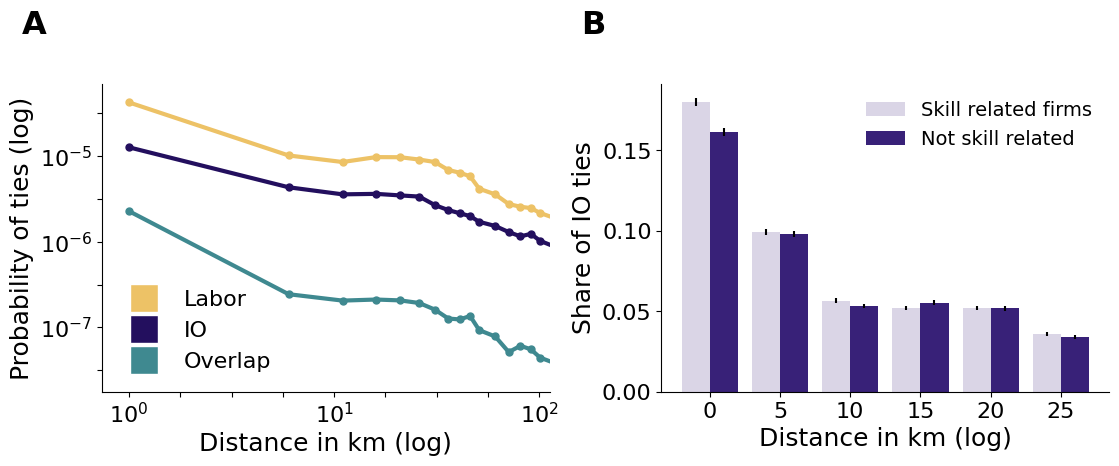

In [8]:
# distance decay figure
fig, ax = plt.subplots(1,2, figsize=(13,4))
plt.subplots_adjust(wspace=0.25)
fontsize=18


# A -- probability of ties
color_dict = {"log_prob_labor":"#EDC266", "log_prob_io":"#230F5E", "log_prob_overlap":"#3F8990"}
legend_text = {"log_prob_labor":"Labor", "log_prob_io":"IO", "log_prob_overlap":"Labor and IO"}
tie_distance(
    ddf2,
    distance_column=["log_dist_combined"],
    var_color_dict=color_dict,
    fontsize=fontsize,
    yaxis_text="Probability of ties (log)",
    legend_dict=legend_text,
    ax=ax[0]
)
ax[0].set_xlim(-0.13270882709389803, 2.05)
ax[0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)
#print(ax[0].get_xlim())
ax[0].set_ylim(-7.75, -4.15)
ax[0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
#ax[0].legend(loc="lower left", prop={'size': fontsize-4}, frameon=False)

custom_legend = [
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#EDC266", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#230F5E", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#3F8990", markersize=20)
]
ax[0].legend(custom_legend, ["Labor", "IO", "Overlap"], loc="lower left", prop={'size': fontsize-2}, frameon=False)


# B -- barplot version
limited_df = ddf2[ddf2["dist_combined"] <= 25]
limited_df["dist_combined"] = limited_df["dist_combined"].astype(int)

bar_width = 0.40
index = np.arange(len(limited_df["dist_combined"]))

ax[1].bar(
        index,
        limited_df["share_io_sr_ties"],
        bar_width,
        label="Skill related firms",
        yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        capsize=0,
        #color="#EDC266"
        #color="#e6e3ed"
        color="#dad5e6"
)

ax[1].bar(
        index + bar_width,
        limited_df["share_io_no_sr_ties"],
        bar_width,
        label="Not skill related",
        yerr=[limited_df["share_io_no_sr_ties_ci"], limited_df["share_io_no_sr_ties_ci"]],
        capsize=0,
        color="#382178"
)
ax[1].set_xticks(index + bar_width / 2, limited_df["dist_combined"], size=fontsize-2)
ax[1].set_xlabel("Distance in km (log)", size=fontsize)
ax[1].set_ylabel("Share of IO ties", size=fontsize)
ax[1].tick_params("y", labelsize=(fontsize-2))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].legend(loc="upper right", prop={'size': fontsize-4}, frameon=False)


# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=fontsize+5)

# plt.savefig(f"../figures/mf03_gravity_share_sr.png", dpi=300, bbox_inches='tight', facecolor="white")

In [16]:
def ei_data_manipulation(path):
    ei_df = pd.read_csv(path, sep=";")
    if len(ei_df["ei_bin"])==21:
        ei_df["group"] = [-1, -1, -0.8, 0.8, -0.6, -0.6, -0.4, -0.4, -0.2, -0.2, 0, 0.2, 0.2, 0.4, 0.4, 0.6, 0.6, 0.8, 0.8, 1, 1]
    else:
        ei_df["group"] = [-1, -0.8, 0.8, -0.6, -0.6, -0.4, -0.4, -0.2, -0.2, 0, 0.2, 0.2, 0.4, 0.4, 0.6, 0.6, 0.8, 0.8, 1, 1]
    
    ei_df["labor_obs2"] = ei_df.groupby("group")["labor_obs"].transform("sum")
    ei_df["io_obs2"] = ei_df.groupby("group")["io_obs"].transform("sum")
    
    ei_df["total_labor"] = ei_df["labor_obs"].sum()
    ei_df["total_io"] = ei_df["io_obs"].sum()
    ei_df["labor_norm"] = ei_df["labor_obs2"] / ei_df["total_labor"]
    ei_df["io_norm"] = ei_df["io_obs2"] / ei_df["total_io"]

    ei_df["se_io_norm"] = np.sqrt(ei_df["io_norm"]*(1-ei_df["io_norm"])) / np.sqrt(ei_df["total_io"])
    ei_df["io_norm_ci"] = 1.96*(ei_df["se_io_norm"])
    ei_df["se_labor_norm"] = np.sqrt(ei_df["labor_norm"]*(1-ei_df["labor_norm"])) / np.sqrt(ei_df["total_labor"])
    ei_df["labor_norm_ci"] = 1.96*(ei_df["se_labor_norm"])

    ei_df = ei_df[["group", "labor_norm", "io_norm", "io_norm_ci", "labor_norm_ci"]].drop_duplicates()
    return ei_df

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_27500/2471178231.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_27500/2471178231.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_27500/2471178231.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

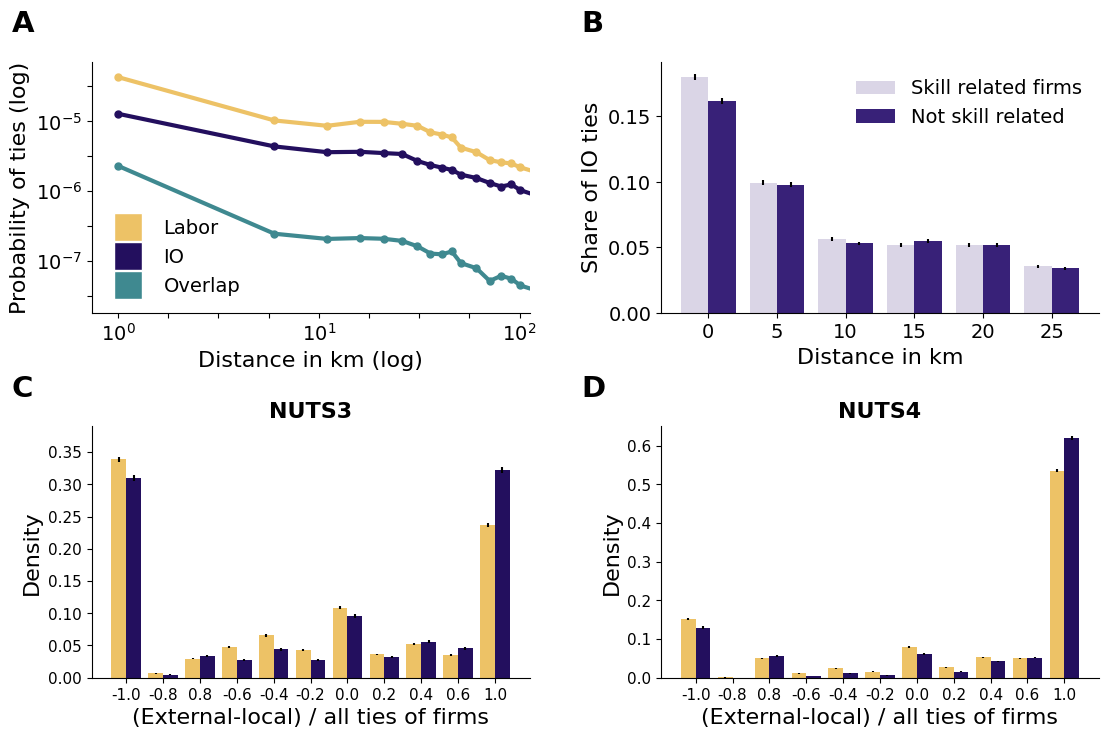

In [24]:
# distance decay figure
fig, ax = plt.subplots(2,2, figsize=(13,8))
plt.subplots_adjust(wspace=0.3, hspace=0.45)
fontsize=16

# A -- probability of ties
color_dict = {"log_prob_labor":"#EDC266", "log_prob_io":"#230F5E", "log_prob_overlap":"#3F8990"}
legend_text = {"log_prob_labor":"Labor", "log_prob_io":"IO", "log_prob_overlap":"Labor and IO"}
tie_distance(
    ddf2,
    distance_column=["log_dist_combined"],
    var_color_dict=color_dict,
    fontsize=fontsize,
    yaxis_text="Probability of ties (log)",
    legend_dict=legend_text,
    ax=ax[0,0]
)
ax[0,0].set_xlim(-0.13270882709389803, 2.05)
ax[0,0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)
#print(ax[0].get_xlim())
ax[0,0].set_ylim(-7.75, -4.15)
ax[0,0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
custom_legend = [
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#EDC266", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#230F5E", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#3F8990", markersize=20)
]
ax[0,0].legend(custom_legend, ["Labor", "IO", "Overlap"], loc="lower left", prop={'size': fontsize-2}, frameon=False)


# B -- barplot version
limited_df = ddf2[ddf2["dist_combined"] <= 25]
limited_df["dist_combined"] = limited_df["dist_combined"].astype(int)

bar_width = 0.40
index = np.arange(len(limited_df["dist_combined"]))

ax[0,1].bar(
        index,
        limited_df["share_io_sr_ties"],
        bar_width,
        label="Skill related firms",
        yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        capsize=0,
        #color="#EDC266"
        #color="#e6e3ed"
        color="#dad5e6"
)

ax[0,1].bar(
        index + bar_width,
        limited_df["share_io_no_sr_ties"],
        bar_width,
        label="Not skill related",
        yerr=[limited_df["share_io_no_sr_ties_ci"], limited_df["share_io_no_sr_ties_ci"]],
        capsize=0,
        color="#382178"
)
ax[0,1].set_xticks(index + bar_width / 2, limited_df["dist_combined"], size=fontsize-2)
ax[0,1].set_xlabel("Distance in km", size=fontsize)
ax[0,1].set_ylabel("Share of IO ties", size=fontsize)
ax[0,1].tick_params("y", labelsize=(fontsize-2))
ax[0,1].spines['top'].set_visible(False)
ax[0,1].spines['right'].set_visible(False)
ax[0,1].legend(loc="upper right", prop={'size': fontsize-2}, frameon=False)





# C -- NUTS3
ei_df = ei_data_manipulation(f"../data/oc15_2023_dec/oc_ei_{region_levels[0].upper()}.csv")
bar_width = 0.4
index = np.arange(len(ei_df["group"]))
ax[1,0].bar(
        index,
        ei_df["labor_norm"],
        bar_width,
        yerr=[ei_df["labor_norm_ci"], ei_df["labor_norm_ci"]],
        capsize=0,
        color="#EDC266"
)
ax[1,0].bar(
        index + bar_width,
        ei_df["io_norm"],
        bar_width,
        yerr=[ei_df["io_norm_ci"], ei_df["io_norm_ci"]],
        capsize=0,
        color="#230F5E"
)
ax[1,0].set_xticks(index + bar_width / 2, ei_df["group"], size=fontsize-2)
ax[1,0].tick_params("x", labelsize=(fontsize-5))
ax[1,0].tick_params("y", labelsize=(fontsize-5))
ax[1,0].spines['top'].set_visible(False)
ax[1,0].spines['right'].set_visible(False)
ax[1,0].set_title("NUTS3", size=fontsize, weight="bold")
ax[1,0].set_ylim(0, 0.39)
ax[1,0].set_xlabel("(External-local) / all ties of firms", size=fontsize)
ax[1,0].set_ylabel("Density", size=fontsize)


# D -- NUTS4
ei_df = ei_data_manipulation(f"../data/oc15_2023_dec/oc_ei_{region_levels[1].upper()}.csv")
bar_width = 0.4
index = np.arange(len(ei_df["group"]))
ax[1,1].bar(
        index,
        ei_df["labor_norm"],
        bar_width,
        yerr=[ei_df["labor_norm_ci"], ei_df["labor_norm_ci"]],
        capsize=0,
        color="#EDC266"
)
ax[1,1].bar(
        index + bar_width,
        ei_df["io_norm"],
        bar_width,
        yerr=[ei_df["io_norm_ci"], ei_df["io_norm_ci"]],
        capsize=0,
        color="#230F5E"
)
ax[1,1].set_xticks(index + bar_width / 2, ei_df["group"], size=fontsize-2)
ax[1,1].tick_params("x", labelsize=(fontsize-5))
ax[1,1].tick_params("y", labelsize=(fontsize-5))
ax[1,1].spines['top'].set_visible(False)
ax[1,1].spines['right'].set_visible(False)
ax[1,1].set_title("NUTS4", size=fontsize, weight="bold")
ax[1,1].set_ylim(0, 0.39)
ax[1,1].set_xlabel("(External-local) / all ties of firms", size=fontsize)
ax[1,1].set_ylabel("Density", size=fontsize)
ax[1,1].set_ylim(0, 0.65)


# subplot title
labels = list(string.ascii_uppercase)[:ax.size]
for i, label in enumerate(labels):
    row, col = divmod(i, ax.shape[1])
    ax[row, col].annotate(label, xy=(0, 1), xycoords='axes fraction', xytext=(-80, 30), textcoords='offset pixels', weight='bold', size=fontsize + 5)


# plt.savefig(f"../figures/mf03_combined_firm-to-firm.png", dpi=300, bbox_inches='tight', facecolor="white")